# Assignment Description: 
This assignment focuses on improving the performance of an image classification model using Convolutional 
Neural Networks (CNN). 

A basic CNN model is first implemented and trained on the Intel Image Classification 
Dataset. 

Then, different techniques such as data augmentation, pretrained VGG16, feature extraction, and fine tuning 
are applied to enhance the model’s accuracy. 

The results of all five approaches are compared to analyse which 
technique performs best for image classification  

# Assignment Objectives: 

In this assignment you will apply five different CNN techniques to improve the performance of an image 
classification model on a challenging dataset. 

You will start with a basic CNN model and gradually improve performance using modern deep learning 
techniques. 

#Assignment Guidelines: 

**Dataset:**
Intel Image Classification Dataset 

https://www.kaggle.com/datasets/puneet6060/intel-image-classification 

Classes include: 

• buildings 

• forest 

• glacier 

• mountain 

• sea 

• street

**1. Basic Convolutional Network** 

Train a simple CNN from scratch. 

Example architecture: 

Conv → ReLU → MaxPool 

Conv → ReLU → MaxPool 

Flatten 

Dense 

Softmax 

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Input
import matplotlib.pyplot as plt

# Dataset paths
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
#test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
#validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"


# Data generators (NO validation_split here)
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# Training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),   # 🔥 reduced size (faster)
    batch_size=64,           # 🔥 bigger batch
    class_mode='categorical' # 🔥 multi-class
)

# Validation data
validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(128,128),
    batch_size=64,
    class_mode='categorical'
)

# CNN Model (modern style)
model = models.Sequential([
    Input(shape=(128,128,3)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256,activation='relu'),

    # 🔥 IMPORTANT: match number of classes
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# Compile model
model.compile(
    loss='categorical_crossentropy',  # 🔥 correct for multi-class
    optimizer=optimizers.Adam(learning_rate=1e-3),  # 🔥 faster than RMSprop
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_generator,
    epochs=10,   # 🔥 start small
    validation_data=validation_generator
)

# Save model
#model.save("model.h5")

2026-03-27 03:19:55.413286: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774581595.570460      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774581595.618417      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774581595.984246      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774581595.984280      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774581595.984283      55 computation_placer.cc:177] computation placer alr

Found 11229 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


I0000 00:00:1774581633.437249      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774581633.443268      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1774581637.643880     142 service.cc:152] XLA service 0x7e82580066b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774581637.643917     142 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774581637.643921     142 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774581638.017376     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/176 ━━━━━━━━━━━━━━━━━━━━ 17:05 6s/step - accuracy: 0.2969 - loss: 1.7710

I0000 00:00:1774581641.553783     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


176/176 ━━━━━━━━━━━━━━━━━━━━ 114s 620ms/step - accuracy: 0.5078 - loss: 1.3062 - val_accuracy: 0.7027 - val_loss: 0.7963
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.7455 - loss: 0.6920 - val_accuracy: 0.7843 - val_loss: 0.6049
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step - accuracy: 0.8062 - loss: 0.5335 - val_accuracy: 0.7917 - val_loss: 0.5741
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.8425 - loss: 0.4359 - val_accuracy: 0.8197 - val_loss: 0.5220
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 23s 132ms/step - accuracy: 0.8875 - loss: 0.3196 - val_accuracy: 0.8220 - val_loss: 0.5258
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - accuracy: 0.9259 - loss: 0.2125 - val_accuracy: 0.8100 - val_loss: 0.5864
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - accuracy: 0.9451 - loss: 0.1537 - val_accuracy: 0.8130 - val_loss: 0.6990
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - accuracy: 0.9696 - loss: 0.0967 - va

**2. Data Augmentation** 

Apply augmentation techniques such as: 

• rotation 

• horizontal flip 

• zoom 

• width/height shift 

Train the CNN again and compare results. 

Found 11229 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Epoch 1/15
 28/176 ━━━━━━━━━━━━━━━━━━━━ 41s 283ms/step - accuracy: 0.3136 - loss: 1.6808

2026-03-27 03:55:41.347424: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.5 = (f16[64,3,3,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[29,63,63,32]{3,2,1,0} %bitcast.6018, f16[29,61,61,64]{3,2,1,0} %bitcast.6043), window={size=3x3}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/sequential_1_1/conv2d_4_1/convolution/Conv2DBackpropFilter" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-03-27 03:55:41.564853: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.217584539s
Trying algorithm eng0{} for

176/176 ━━━━━━━━━━━━━━━━━━━━ 77s 369ms/step - accuracy: 0.4663 - loss: 1.3449 - val_accuracy: 0.6460 - val_loss: 0.9212
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 310ms/step - accuracy: 0.6418 - loss: 0.9267 - val_accuracy: 0.6853 - val_loss: 0.8429
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 313ms/step - accuracy: 0.6930 - loss: 0.8257 - val_accuracy: 0.7757 - val_loss: 0.6264
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 314ms/step - accuracy: 0.7251 - loss: 0.7403 - val_accuracy: 0.7820 - val_loss: 0.6186
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 54s 306ms/step - accuracy: 0.7378 - loss: 0.7026 - val_accuracy: 0.7977 - val_loss: 0.5672
Epoch 6/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 54s 308ms/step - accuracy: 0.7786 - loss: 0.6282 - val_accuracy: 0.8060 - val_loss: 0.5508
Epoch 7/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 54s 308ms/step - accuracy: 0.7831 - loss: 0.5890 - val_accuracy: 0.8080 - val_loss: 0.5557
Epoch 8/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 54s 308ms/step - accuracy: 0.7896 - loss: 0.5759 - val

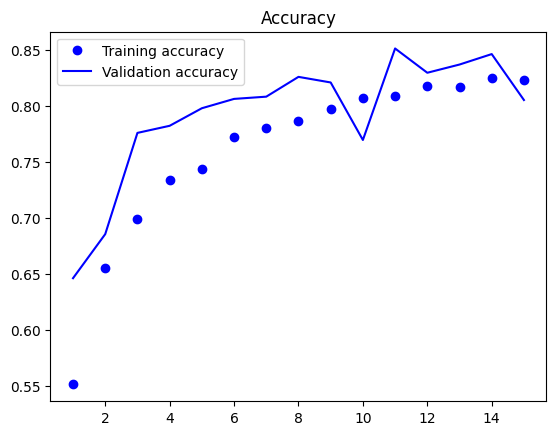

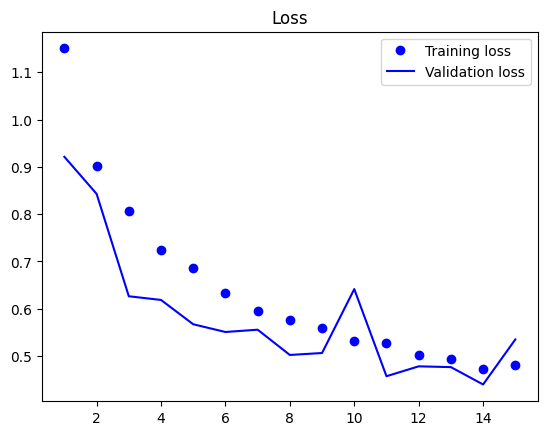

In [2]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt

# 🔥 Enable GPU optimization
mixed_precision.set_global_policy('mixed_float16')

# Image Augmentation (train only)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,          # reduced (faster)
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)

# 🚀 Faster config
IMG_SIZE = (128, 128)
BATCH_SIZE = 64

# Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # 🔥 auto multi-class
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# 🔍 Check classes
print("Classes:", train_generator.class_indices)

# Model
model = models.Sequential([
    Input(shape=(128,128,3)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dropout(0.5),

    layers.Dense(256,activation='relu'),

    # 🔥 auto match classes
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-3),  # 🔥 faster
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_generator,
    epochs=15,   # 🔥 reduced (faster)
    validation_data=validation_generator
)

# Save model
#model.save("/content/drive/MyDrive/Colab Notebooks/DL/assignment/augmentation_model2.h5")

# Plot
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc)+1)

plt.plot(epochs,acc,'bo',label='Training accuracy')
plt.plot(epochs,val_acc,'b',label='Validation accuracy')
plt.legend()
plt.title('Accuracy')

plt.figure()

plt.plot(epochs,loss,'bo',label='Training loss')
plt.plot(epochs,val_loss,'b',label='Validation loss')
plt.legend()
plt.title('Loss')

plt.show()

**3. Pretrained CNN (VGG16)** 

Use VGG16 pretrained on ImageNet. 

Freeze the convolutional base and train only the classifier.

Found 11229 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1774587184.613116     131 service.cc:152] XLA service 0x7c1d18003750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774587184.613157     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774587184.613164     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774587184.784581     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/176 ━━━━━━━━━━━━━━━━━━━━ 36:19 12s/step

I0000 00:00:1774587196.649890     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


176/176 ━━━━━━━━━━━━━━━━━━━━ 83s 403ms/step
Found 3000 images belonging to 6 classes.
47/47 ━━━━━━━━━━━━━━━━━━━━ 30s 638ms/step
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5693 - loss: 1.0983 - val_accuracy: 0.8223 - val_loss: 0.4940
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8106 - loss: 0.5232 - val_accuracy: 0.8383 - val_loss: 0.4345
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8318 - loss: 0.4570 - val_accuracy: 0.8517 - val_loss: 0.4081
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8484 - loss: 0.4175 - val_accuracy: 0.8567 - val_loss: 0.3888
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8542 - loss: 0.3860 - val_accuracy: 0.8613 - val_loss: 0.3749
Epoch 6/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8591 - loss: 0.3807 - val_accuracy: 0.8573 - val_loss: 0.3758
Epoch 7/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8598 - loss: 0.3706 - val_accuracy: 0.8607 - val_loss: 0.3637
Epoch 8/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8726 - loss: 0.3500 - val_accuracy: 0.8667 - val

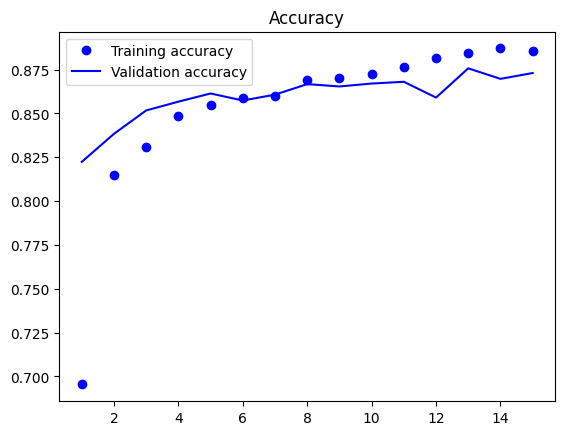

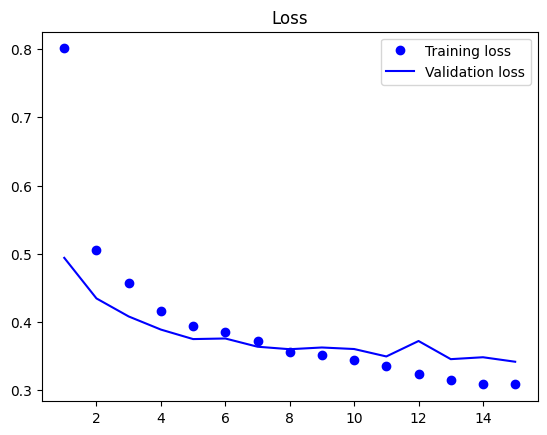

In [2]:
# Load VGG16
from tensorflow.keras.applications import VGG16

conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)   # 🔥 reduced size (faster)
)

conv_base.trainable = False   # 🔥 freeze for speed


# Data Generator
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset paths
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
#test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
#validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"

datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 64   # 🔥 faster


def extract_features(directory):

    generator = datagen.flow_from_directory(
        directory,
        target_size=(128,128),
        batch_size=BATCH_SIZE,
        class_mode='categorical',   # 🔥 multi-class
        shuffle=False
    )

    features = conv_base.predict(generator, verbose=1)
    labels = generator.classes

    return features, labels, generator.num_classes


# Extract features
train_features, train_labels, num_classes = extract_features(train_dir)
val_features, val_labels, _ = extract_features(validation_dir)


# 🔥 Better than flatten (reduces size)
from tensorflow.keras.layers import GlobalAveragePooling2D

train_features = train_features.mean(axis=(1,2))
val_features = val_features.mean(axis=(1,2))


# Convert labels to categorical
from tensorflow.keras.utils import to_categorical

train_labels = to_categorical(train_labels, num_classes)
val_labels = to_categorical(val_labels, num_classes)


# Dense classifier
from tensorflow.keras import models, layers, optimizers

model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(512,)),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')   # 🔥 auto classes
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),  # 🔥 faster
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Train
history = model.fit(
    train_features,
    train_labels,
    epochs=15,           # 🔥 reduced
    batch_size=64,
    validation_data=(val_features, val_labels)
)

#model.save("/content/drive/MyDrive/Colab Notebooks/DL/assignment/vgg16_feature_model.h5")

# Plot
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc)+1)

plt.plot(epochs,acc,'bo',label='Training accuracy')
plt.plot(epochs,val_acc,'b',label='Validation accuracy')
plt.legend()
plt.title('Accuracy')

plt.figure()

plt.plot(epochs,loss,'bo',label='Training loss')
plt.plot(epochs,val_loss,'b',label='Validation loss')
plt.legend()
plt.title('Loss')

plt.show()

# 4. Feature Extraction 

Use VGG16 to extract features, then train a small classifier on top. 

Steps: 

Image → VGG16 (frozen) → feature vector → classifier 

Found 11229 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 82s 402ms/step - accuracy: 0.2458 - loss: 1.7979 - val_accuracy: 0.6730 - val_loss: 1.2232
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 54s 308ms/step - accuracy: 0.5348 - loss: 1.2248 - val_accuracy: 0.7383 - val_loss: 0.9450
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 313ms/step - accuracy: 0.6527 - loss: 0.9812 - val_accuracy: 0.7617 - val_loss: 0.7939
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 54s 309ms/step - accuracy: 0.6920 - loss: 0.8664 - val_accuracy: 0.7707 - val_loss: 0.7126
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 312ms/step - accuracy: 0.7240 - loss: 0.7771 - val_accuracy: 0.7847 - val_loss: 0.6565
Epoch 6/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 310ms/step - accuracy: 0.7302 - loss: 0.7407 - val_accuracy: 0.7947 - val_loss: 0.6150
Epoch 7/15
176/176 ━━━━━━━━━━━━━━━━━━━

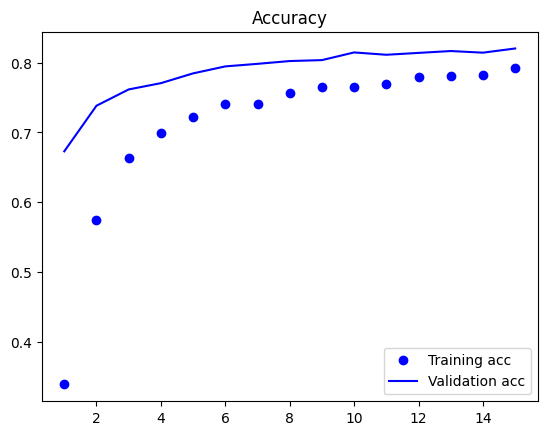

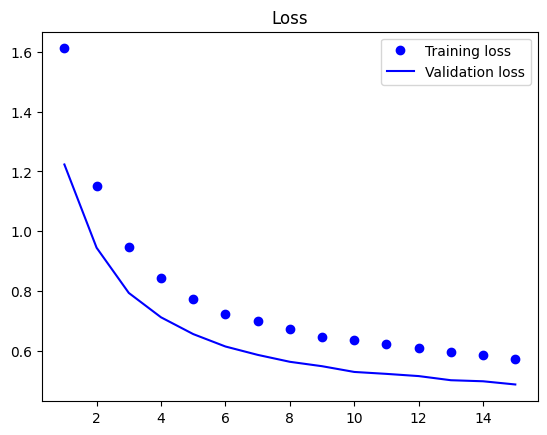

In [3]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, GlobalAveragePooling2D
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt

# 🔥 GPU optimization
mixed_precision.set_global_policy('mixed_float16')

# Load VGG16
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

conv_base.trainable = False

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 64

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # ✅ changed
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(128,128),
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # ✅ changed
)

# 🔍 Check classes
print("Classes:", train_generator.class_indices)
num_classes = train_generator.num_classes

# Model
model = models.Sequential([
    Input(shape=(128,128,3)),
    conv_base,
    GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')   # ✅ changed
])

# Compile
model.compile(
    loss='categorical_crossentropy',   # ✅ changed
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)

# 💾 Save model
# model.save("/content/drive/MyDrive/Colab Notebooks/DL/assignment/vgg16_categorical.keras")

# Plot
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.legend()
plt.title('Accuracy')

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.legend()
plt.title('Loss')

plt.show()

**5. Fine Tuning**

Unfreeze the top layers of VGG16 and retrain them along with the classifier. 

This allows the network to adapt to the dataset.

Found 11229 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 63s 336ms/step - accuracy: 0.2781 - loss: 1.7415 - val_accuracy: 0.6657 - val_loss: 1.2004
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 314ms/step - accuracy: 0.5564 - loss: 1.1947 - val_accuracy: 0.7277 - val_loss: 0.9248
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 316ms/step - accuracy: 0.6459 - loss: 0.9742 - val_accuracy: 0.7500 - val_loss: 0.7894
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 315ms/step - accuracy: 0.6962 - loss: 0.8525 - val_accuracy: 0.7643 - val_loss: 0.7025
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 318ms/step - accuracy: 0.7115 - loss: 0.7885 - val_accuracy: 0.7767 - val_loss: 0.6510
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 315ms/step - accuracy: 0.7361 - loss: 0.7306 - val_accuracy: 0.7920 - val_loss: 0.6135
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━

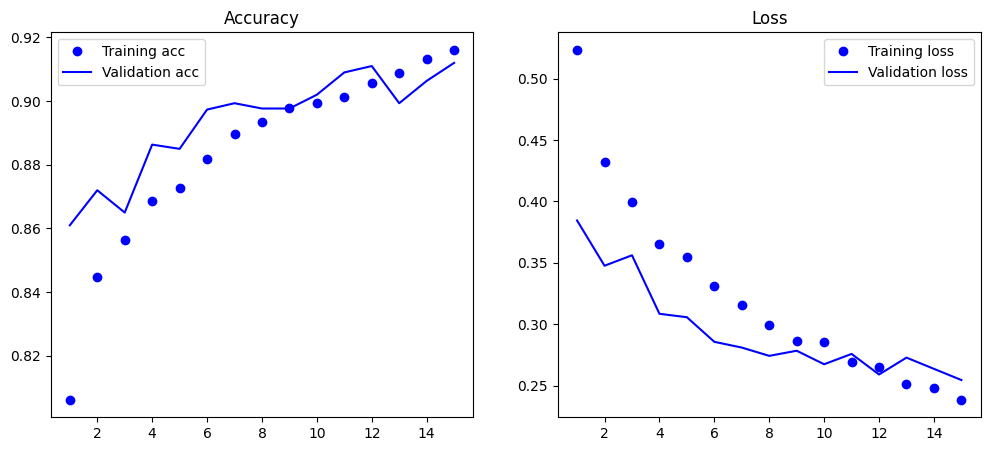

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, GlobalAveragePooling2D
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt
# Dataset paths
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
#test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
#validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"


# 🔥 GPU optimization
mixed_precision.set_global_policy('mixed_float16')

# Load VGG16 base
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)   # ⚡ faster
)

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 64

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # ✅ changed
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # ✅ changed
)

# 🔍 Check classes
print("Classes:", train_generator.class_indices)
num_classes = train_generator.num_classes

# Build model (better than Flatten)
model = models.Sequential([
    Input(shape=(128,128,3)),
    conv_base,
    GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')   # ✅ changed
])

# Freeze base initially
conv_base.trainable = False

# Compile (initial training)
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# Train top layers
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# 🔥 Fine-tuning (unfreeze last layers)
conv_base.trainable = True

for layer in conv_base.layers[:-4]:   # keep most frozen
    layer.trainable = False

# Recompile with lower LR
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

# Fine-tune
history_fine = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)

# Plot results
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']
loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.legend()
plt.title('Loss')

plt.show()

| Model | Type                     | Validation Accuracy |
| ----- | ------------------------ | ------------------- |
| 1️⃣   | Simple CNN               | **0.8057**          |
| 2️⃣   | CNN + Augmentation       | **0.8050**          |
| 3️⃣   | VGG16 Feature Extraction | **0.8730**          |
| 4️⃣   | VGG16 + Augmentation     | **0.8203**          |
| 5️⃣   | VGG16 + Fine-tuning      | **0.9120**          |


🔹 1. Simple CNN → Baseline - 0.80

Model is learning basic patterns

Limited feature extraction

Good starting point

🔹 2. Augmentation →  0.80

Helps generalization


🔹 3. VGG16 Feature Extraction → BIG JUMP - 0.8730

This is expected: Uses pretrained knowledge (ImageNet)

Strong feature extractor

Huge improvement over CNN

4. VGG16 + Augmentation → DROP - 0.8203 - This is interesting

Possible Reasons:

Too much augmentation (over-distortion)

Model already strong → augmentation adds noise

Underfitting due to frozen layers

This is a common real-world scenario

5. VGG16 + Fine-Tuning → BEST - 0.9120

Highest accuracy

Model adapts to your dataset

This is your final best model

**Overall Trend : CNN → +Aug → +VGG → +Aug(VGG) ↓ → +FineTune ↑**

Key takeaway:

Transfer learning > Custom CNN

Fine-tuning > Feature extraction

Too much augmentation can hurt

**Final Conclusion Best Model**

1.VGG16 + Fine-tuning (0.9120)

2.VGG16 Feature Extraction (0.8795)